## Day 1 — Vision Transformer Autopsy

This notebook investigates how a Vision Transformer converts an image
into patch tokens and processes them using Transformer encoder blocks.

### Model studied

- Architecture: ViT-Base
- Input resolution: 224 × 224
- Patch size: 16 × 16
- Patch tokens: 196
- CLS tokens: 1
- Total tokens: 197
- Hidden dimension: 768
- Transformer blocks: 12
- Attention heads: 12
- MLP dimension: 3072

In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw
from torchvision.transforms.functional import to_tensor

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

**ViT configuration**

In [3]:
IMAGE_SIZE = 224
PATCH_SIZE = 16
CHANNELS = 3
HIDDEN_SIZE = 768

PATCHES_PER_SIDE = IMAGE_SIZE // PATCH_SIZE
NUM_PATCHES = PATCHES_PER_SIDE ** 2

FLATTENED_PATCH_SIZE = PATCH_SIZE * PATCH_SIZE * CHANNELS
TOTAL_TOKENS = NUM_PATCHES + 1

print(f"Patches per side     : {PATCHES_PER_SIDE}")
print(f"Number of patches    : {NUM_PATCHES}")
print(f"Flattened patch size : {FLATTENED_PATCH_SIZE}")
print(f"Total tokens         : {TOTAL_TOKENS}")

Patches per side     : 14
Number of patches    : 196
Flattened patch size : 768
Total tokens         : 197


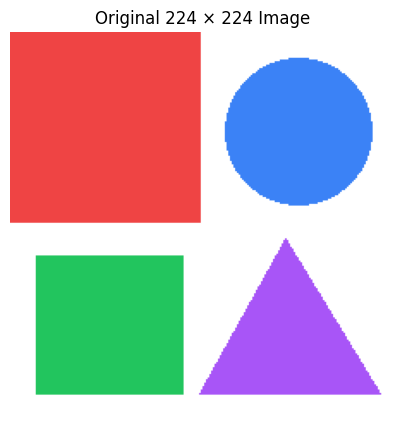

In [4]:
image = Image.new("RGB", (IMAGE_SIZE, IMAGE_SIZE), color="white")
draw = ImageDraw.Draw(image)

draw.rectangle((0, 0, 110, 110), fill=(239, 68, 68))
draw.ellipse((125, 15, 210, 100), fill=(59, 130, 246))
draw.rectangle((15, 130, 100, 210), fill=(34, 197, 94))
draw.polygon(
    [(160, 120), (215, 210), (110, 210)],
    fill=(168, 85, 247)
)

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.title("Original 224 × 224 Image")
plt.axis("off")
plt.show()

**Image tensor inspection**

In [5]:
image_tensor = to_tensor(image)

print("Image tensor shape:", image_tensor.shape)
print("Data type:", image_tensor.dtype)
print("Minimum pixel value:", image_tensor.min().item())
print("Maximum pixel value:", image_tensor.max().item())

Image tensor shape: torch.Size([3, 224, 224])
Data type: torch.float32
Minimum pixel value: 0.13333334028720856
Maximum pixel value: 1.0


**Manual patchify() function**

In [6]:
def patchify(image_tensor, patch_size):
    channels, height, width = image_tensor.shape
    assert height % patch_size == 0
    assert width % patch_size == 0
    
    patches = image_tensor.unfold(
        dimension=1,
        size=patch_size,
        step=patch_size
    )
    
    patches = patches.unfold(
        dimension=2,
        size=patch_size,
        step=patch_size
    )
    
    patches = patches.permute(1, 2, 0, 3, 4).contiguous()
    patches = patches.view(
        -1, channels,
        patch_size, patch_size
    )
    return patches


patches = patchify(image_tensor, PATCH_SIZE)
print("Patch tensor shape:", patches.shape)

Patch tensor shape: torch.Size([196, 3, 16, 16])


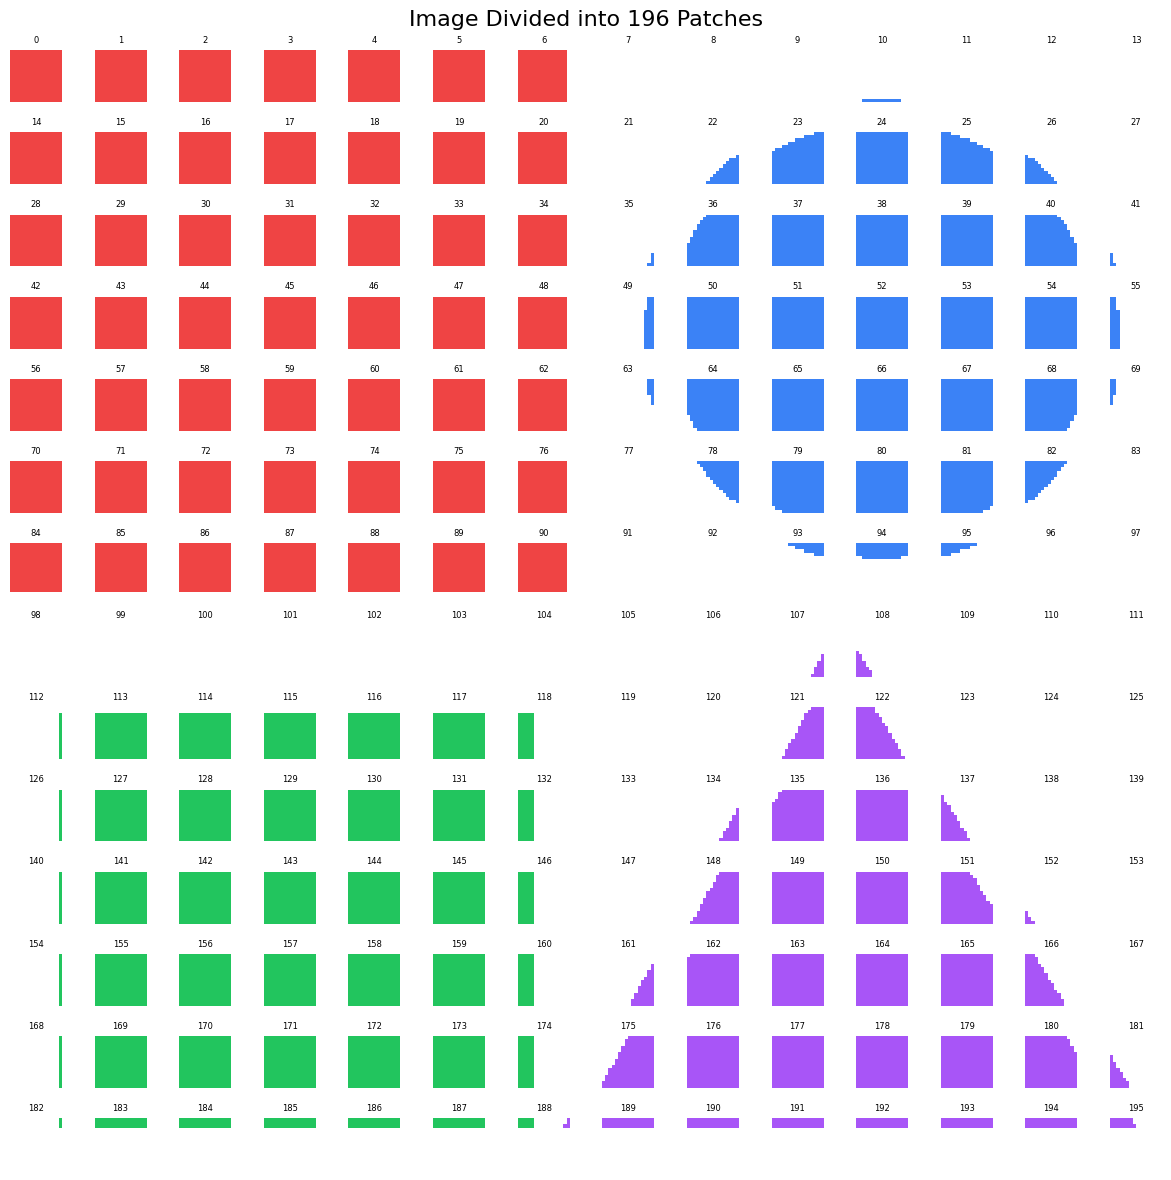

In [8]:
fig, axes = plt.subplots(
    PATCHES_PER_SIDE, PATCHES_PER_SIDE, figsize=(12, 12)
)

for index, axis in enumerate(axes.flat):
    patch = patches[index].permute(1, 2, 0)
    
    axis.imshow(patch)
    axis.set_title(str(index), fontsize=6)
    axis.axis("off")

plt.suptitle("Image Divided into 196 Patches", fontsize=16)
plt.tight_layout()
plt.show()

**Flatten every patch** 

In [9]:
flattened_patches = patches.flatten(start_dim=1)

print("Before flattening:", patches.shape)
print("After flattening :", flattened_patches.shape)

Before flattening: torch.Size([196, 3, 16, 16])
After flattening : torch.Size([196, 768])


**Linear patch projection**

In [10]:
patch_projection = nn.Linear(
    in_features=FLATTENED_PATCH_SIZE,
    out_features=HIDDEN_SIZE
)

patch_embeddings = patch_projection(flattened_patches)

print("Raw flattened patches:", flattened_patches.shape)
print("Projected embeddings :", patch_embeddings.shape)

Raw flattened patches: torch.Size([196, 768])
Projected embeddings : torch.Size([196, 768])


**Adding Batch dimension**

In [11]:
patch_embeddings = patch_embeddings.unsqueeze(0)

print("Patch embeddings with batch:", patch_embeddings.shape)

Patch embeddings with batch: torch.Size([1, 196, 768])


**Add CLS token**

In [13]:
batch_size = patch_embeddings.shape[0]

cls_token = nn.Parameter(
    torch.zeros(1, 1, HIDDEN_SIZE)
)

expanded_cls_token = cls_token.expand(
    batch_size, -1, -1
)

tokens_with_cls = torch.cat(
    [expanded_cls_token, patch_embeddings], dim=1
)

print("CLS token shape :", expanded_cls_token.shape)
print("Final token shape:", tokens_with_cls.shape)

CLS token shape : torch.Size([1, 1, 768])
Final token shape: torch.Size([1, 197, 768])


**Position embeddings**

In [14]:
position_embeddings = nn.Parameter(
    torch.zeros(1, TOTAL_TOKENS, HIDDEN_SIZE)
)

nn.init.trunc_normal_(position_embeddings, std=0.02)
input_tokens = tokens_with_cls + position_embeddings

print("Tokens before position embedding:", tokens_with_cls.shape)
print("Position embeddings shape       :", position_embeddings.shape)
print("Transformer input shape         :", input_tokens.shape)

Tokens before position embedding: torch.Size([1, 197, 768])
Position embeddings shape       : torch.Size([1, 197, 768])
Transformer input shape         : torch.Size([1, 197, 768])


In [16]:
assert patches.shape == (196, 3, 16, 16)
assert flattened_patches.shape == (196, 768)
assert patch_embeddings.shape == (1, 196, 768)
assert tokens_with_cls.shape == (1, 197, 768)
assert input_tokens.shape == (1, 197, 768)